# 02 - Preprocessing Sanity Check
 
**Goal:** To test our complete data pipeline (`config` -> `dataset.py` -> `transforms.py`) before writing the training loop.
# 
We will:
1.  Add the `src` directory to our Python path.
2.  Load the `unet_baseline.yaml` configuration file.
3.  Call `get_data_loaders()` from `src.data.dataset` to build our `train_loader` and `val_loader`.
4.  Fetch **one batch** from the `train_loader`.
5.  Inspect the batch's shape, data type, and value range.
6.  **Visually plot** a slice from each patch in the batch to confirm the image and label are aligned and normalized.
7.  Inspect one batch from the `val_loader` to confirm it's loading a full-sized (non-patched) volume.

In [1]:
import os
import sys
import yaml
import matplotlib.pyplot as plt
import numpy as np
import torch

# --- This is the most important part ---
# Add the project's root directory to the Python path
# This allows us to import from the 'src' module
# (e.g., `from src.data.dataset import ...`)
notebook_dir = os.path.dirname(os.path.abspath("__file__" if "__file__" in locals() else os.getcwd()))
# The project root is the directory containing the 'src' folder.
# In this case, it's the same as the notebook's directory.
project_root = notebook_dir

if project_root not in sys.path:
    print(f"Adding {project_root} to sys.path")
    sys.path.append(project_root)

# Now we can import our custom modules
from src.data.dataset import get_data_loaders

Adding /home/noahschuetz/GitHub/mip to sys.path


## 1. Load Configuration
We'll load the YAML file just like `train.py` will.

In [2]:
CONFIG_FILE_PATH = os.path.join(project_root, "configs/unet_baseline.yaml")

print(f"Loading config from: {CONFIG_FILE_PATH}")

if not os.path.exists(CONFIG_FILE_PATH):
    print(f"Error: Config file not found at {CONFIG_FILE_PATH}")
    print("Please make sure you have created 'configs/unet_baseline.yaml'")
else:
    with open(CONFIG_FILE_PATH, 'r') as f:
        config = yaml.safe_load(f)
    
    print("--- Config Loaded Successfully ---")
    print(yaml.dump(config, default_flow_style=False))
    print("----------------------------------")

Loading config from: /home/noahschuetz/GitHub/mip/configs/unet_baseline.yaml
--- Config Loaded Successfully ---
data:
  data_dir: ./data/raw
  patch_size:
  - 96
  - 96
  - 96
  val_split: 0.2
device: cuda
experiment_name: unet_baseline
model:
  name: baseline_unet
results_dir: ./results/unet_baseline
training:
  batch_size: 2
  learning_rate: 1e-4
  num_epochs: 100

----------------------------------


## 2. Build DataLoaders

This is the main test. We pass our config dictionaries to `get_data_loaders()`.

This will trigger `_get_data_files()` to scan your directories and `CacheDataset` to start preprocessing and caching.

**This cell might take a minute** as it processes and caches your data.

In [3]:
try:
    data_config = config["data"]
    training_config = config["training"]
    
    # Adjust data_dir path to be absolute, just in case
    if not os.path.isabs(data_config["data_dir"]):
        data_config["data_dir"] = os.path.join(project_root, data_config["data_dir"])
        print(f"Resolved data_dir to: {data_config['data_dir']}")
        
    train_loader, val_loader = get_data_loaders(
        data_config=data_config,
        training_config=training_config
    )
    print("\nSuccessfully created train_loader and val_loader.")
    
except Exception as e:
    print(f"\n--- An Error Occurred ---")
    print(f"Error: {e}")
    print("\nCommon issues:")
    print("1. Is the 'data_dir' in unet_baseline.yaml correct?")
    print("2. Is your file structure exactly as specified in dataset.py?")
    print("3. Did you 'pip install PyYAML'?")

monai.transforms.spatial.dictionary Orientationd.__init__:labels: Current default value of argument `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` was changed in version None from `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` to `labels=None`. Default value changed to None meaning that the transform now uses the 'space' of a meta-tensor, if applicable, to determine appropriate axis labels.


Resolved data_dir to: /home/noahschuetz/GitHub/mip/./data/raw
Found 200 potential subjects.
Successfully found 200 complete subjects.
Data split: 160 training, 40 validation.
Creating datasets and caching... (This may take a moment)


Loading dataset: 100%|██████████| 40/40 [00:40<00:00,  1.00s/it]


Successfully created train_loader and val_loader.


## 3. Inspect Training Batch

Let's pull one batch from the `train_loader` and check its properties.

In [4]:
# Get one batch
train_batch = next(iter(train_loader))
img, lbl = train_batch["image"], train_batch["label"]

# --- Check Properties ---
print("--- Training Batch Properties ---")
print(f"Batch 'image' shape: {img.shape}")
print(f"Batch 'label' shape: {lbl.shape}")
print(f"Batch 'image' dtype: {img.dtype}")
print(f"Batch 'label' dtype: {lbl.dtype}")

# --- Check Value Ranges (Normalization) ---
print("\n--- Value Ranges ---")
print(f"Image min: {img.min():.4f}, max: {img.max():.4f}")
print(f"Label min: {lbl.min():.4f}, max: {lbl.max():.4f}")
print(f"Label unique values: {torch.unique(lbl)}")

# --- Check Config vs. Reality ---
expected_batch_size = config["training"]["batch_size"]
expected_patch_size = config["data"]["patch_size"]



print("\n--- Sanity Checks ---")
print(f"Batch size matches config: {img.shape[0] == expected_batch_size}")
print(f"Expected batch size: {expected_batch_size}, Actual: {img.shape[0]}")
print(f"Patch size matches config: {list(img.shape[2:]) == expected_patch_size}")
print(f"Expected patch size: {expected_patch_size}, Actual: {list(img.shape[2:])}")
print(f"Image normalized (0-1): {img.min() >= 0.0 and img.max() <= 1.0}")
print(f"Label is binary (0-1): {lbl.min() >= 0.0 and lbl.max() <= 1.0}")

--- Training Batch Properties ---
Batch 'image' shape: torch.Size([2, 1, 96, 96, 96])
Batch 'label' shape: torch.Size([2, 1, 96, 96, 96])
Batch 'image' dtype: torch.float32
Batch 'label' dtype: torch.float32

--- Value Ranges ---
Image min: 0.0000, max: 1.0000
Label min: 0.0000, max: 1.0000
Label unique values: tensor([0., 1.])

--- Sanity Checks ---
Batch size matches config: True
Expected batch size: 2, Actual: 2
Patch size matches config: True
Expected patch size: [96, 96, 96], Actual: [96, 96, 96]
Image normalized (0-1): True
Label is binary (0-1): True


## 4. Visualize Training Batch

This is the most important step. We'll plot a middle slice from each patch in the batch to **visually confirm** that the image (normalized CT) and label (artery mask) are correctly aligned.

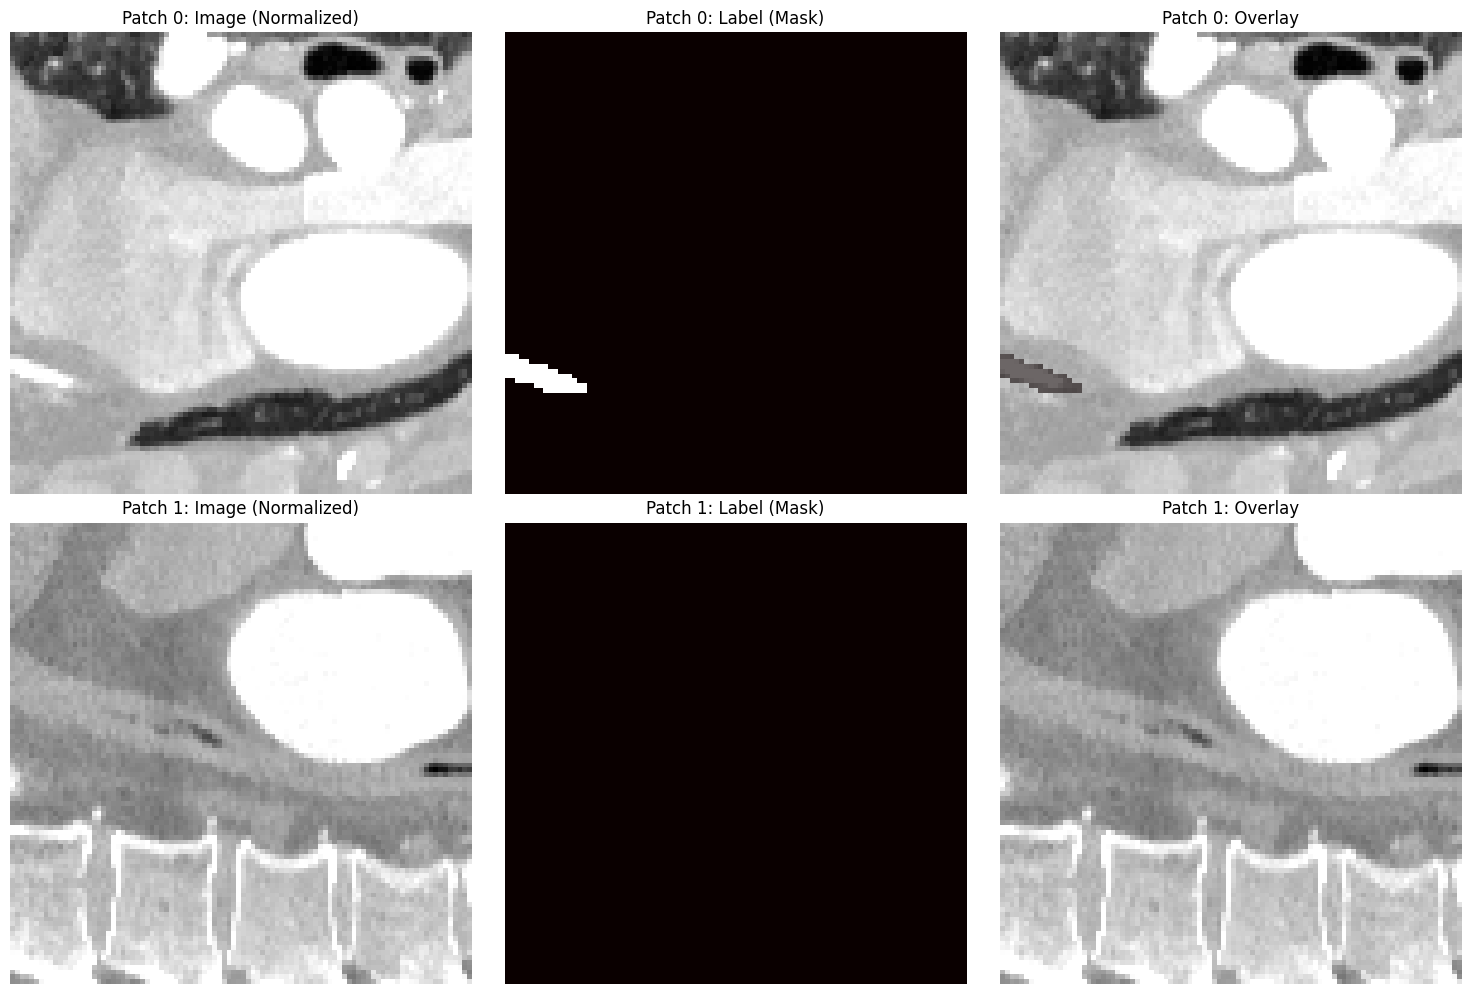

In [6]:
# Get batch size (B) and patch depth (D)
B = img.shape[0]
D = img.shape[2]
middle_slice_idx = D // 2

# Create a (B, 3) grid: (Image, Label, Overlay) for each item in the batch
fig, ax = plt.subplots(
    B, 3, 
    figsize=(15, B * 5), 
    squeeze=False # Ensures ax is always 2D
)

for i in range(B):
    # Get the middle slice (e.g., slice 48 of 96)
    # Shape (1, 96, 96, 96) -> (96, 96)
    img_slice = img[i, 0, middle_slice_idx, :, :].cpu().numpy()
    lbl_slice = lbl[i, 0, middle_slice_idx, :, :].cpu().numpy()
    
    # --- 1. Plot Image Slice ---
    ax[i, 0].imshow(img_slice, cmap='gray')
    ax[i, 0].set_title(f"Patch {i}: Image (Normalized)")
    ax[i, 0].axis('off')
    
    # --- 2. Plot Label Slice ---
    ax[i, 1].imshow(lbl_slice, cmap='hot')
    ax[i, 1].set_title(f"Patch {i}: Label (Mask)")
    ax[i, 1].axis('off')
    
    # --- 3. Plot Overlay ---
    ax[i, 2].imshow(img_slice, cmap='gray')
    # Use a masked array to only show label pixels > 0
    masked_label = np.ma.masked_where(lbl_slice == 0, lbl_slice)
    ax[i, 2].imshow(masked_label, cmap='hot', alpha=0.6)
    ax[i, 2].set_title(f"Patch {i}: Overlay")
    ax[i, 2].axis('off')

plt.tight_layout()
plt.show()

## 5. Inspect Validation Batch

Finally, let's check one batch from the `val_loader`.

We expect the `batch_size` to be 1, and the dimensions `(D, H, W)` to be the **full, resampled volume**, not a small 96x96x96 patch. This confirms it's ready for `sliding_window_inference`.

In [7]:
# Get one batch
val_batch = next(iter(val_loader))
img_val, lbl_val = val_batch["image"], val_batch["label"]

# --- Check Properties ---
print("--- Validation Batch Properties ---")
print(f"Batch 'image' shape: {img_val.shape}")
print(f"Batch 'label' shape: {lbl_val.shape}")
print(f"Batch 'image' dtype: {img_val.dtype}")
print(f"Batch 'label' dtype: {lbl_val.dtype}")

# --- Check Value Ranges (Normalization) ---
print("\n--- Value Ranges ---")
print(f"Image min: {img_val.min():.4f}, max: {img_val.max():.4f}")
print(f"Label min: {lbl_val.min():.4f}, max: {lbl_val.max():.4f}")
print(f"Label unique values: {torch.unique(lbl_val)}")

# --- Check Config vs. Reality ---
print("\n--- Sanity Checks ---")
print(f"Batch size is 1: {img_val.shape[0] == 1}")
print(f"Image is full volume (not patch): {img_val.shape[2] > 96}")
print(f"Image normalized (0-1): {img_val.min() >= 0.0 and img_val.max() <= 1.0}")

--- Validation Batch Properties ---
Batch 'image' shape: torch.Size([1, 1, 177, 177, 138])
Batch 'label' shape: torch.Size([1, 1, 177, 177, 138])
Batch 'image' dtype: torch.float32
Batch 'label' dtype: torch.float32

--- Value Ranges ---
Image min: 0.0000, max: 1.0000
Label min: 0.0000, max: 1.0000
Label unique values: tensor([0., 1.])

--- Sanity Checks ---
Batch size is 1: True
Image is full volume (not patch): True
Image normalized (0-1): True


## 6. Conclusion

If all cells ran without error and the visualization (Cell 5) looks correct, then **our entire data pipeline is working!**

- We can successfully read the YAML config.
- We can successfully find and split our data files.
- We can successfully preprocess, augment, cache, and load patches for training.
- We can successfully preprocess and load full volumes for validation.

We are now 100% ready to write the main `src/train.py` script.